In [1]:

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

In [2]:

mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
baseline_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9201 - loss: 0.2721 - val_accuracy: 0.9556 - val_loss: 0.1449
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9656 - loss: 0.1125 - val_accuracy: 0.9653 - val_loss: 0.1116
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9772 - loss: 0.0745 - val_accuracy: 0.9728 - val_loss: 0.0962
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0562 - val_accuracy: 0.9733 - val_loss: 0.0933
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9861 - loss: 0.0422 - val_accuracy: 0.9748 - val_loss: 0.0919
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9885 - loss: 0.0344 - val_accuracy: 0.9730 - val_loss: 0.1010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9909 - loss: 0.0287 - val_accuracy: 0.9703 - val_loss: 0.1114
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0247 - 

In [4]:
dropout_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = dropout_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8053 - loss: 0.6324 - val_accuracy: 0.9405 - val_loss: 0.2063
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9026 - loss: 0.3437 - val_accuracy: 0.9547 - val_loss: 0.1646
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9204 - loss: 0.2858 - val_accuracy: 0.9605 - val_loss: 0.1419
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9277 - loss: 0.2574 - val_accuracy: 0.9629 - val_loss: 0.1341
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9345 - loss: 0.2326 - val_accuracy: 0.9657 - val_loss: 0.1230
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9387 - loss: 0.2212 - val_accuracy: 0.9667 - val_loss: 0.1228
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9411 - loss: 0.2099 - val_accuracy: 0.9647 - val_loss: 0.1208
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9428 - loss: 0.1994 - 

In [5]:
l2_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = l2_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9194 - loss: 0.4516 - val_accuracy: 0.9567 - val_loss: 0.2946
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9580 - loss: 0.2797 - val_accuracy: 0.9613 - val_loss: 0.2564
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9637 - loss: 0.2383 - val_accuracy: 0.9678 - val_loss: 0.2261
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9671 - loss: 0.2163 - val_accuracy: 0.9690 - val_loss: 0.2111
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9700 - loss: 0.2022 - val_accuracy: 0.9690 - val_loss: 0.2054
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9710 - loss: 0.1943 - val_accuracy: 0.9700 - val_loss: 0.1972
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9731 - loss: 0.1825 - val_accuracy: 0.9696 - val_loss: 0.1961
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9734 - loss: 0.1781 - 

In [6]:
batchnorm_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
])

batchnorm_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_batchnorm = batchnorm_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9219 - loss: 0.2759 - val_accuracy: 0.9609 - val_loss: 0.1317
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9631 - loss: 0.1213 - val_accuracy: 0.9721 - val_loss: 0.0929
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9720 - loss: 0.0921 - val_accuracy: 0.9702 - val_loss: 0.0958
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9757 - loss: 0.0743 - val_accuracy: 0.9749 - val_loss: 0.0823
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9807 - loss: 0.0600 - val_accuracy: 0.9744 - val_loss: 0.0884
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9832 - loss: 0.0503 - val_accuracy: 0.9725 - val_loss: 0.0909
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9844 - loss: 0.0474 - val_accuracy: 0.9765 - val_loss: 0.0833
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0416 - 

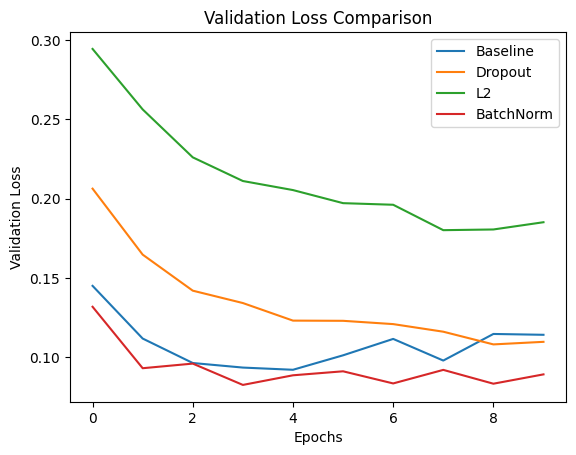

In [7]:

plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_batchnorm.history['val_loss'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()

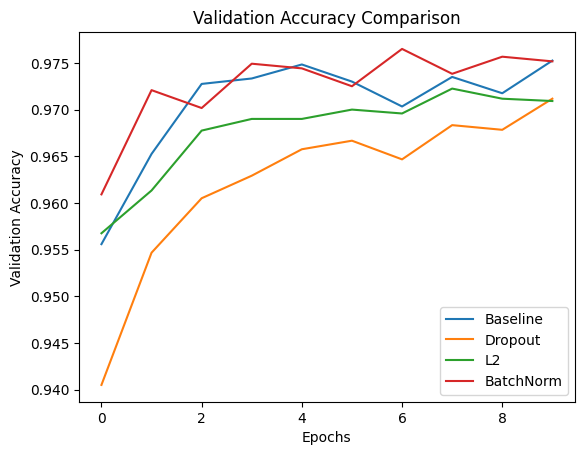

In [8]:

plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_batchnorm.history['val_accuracy'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()
